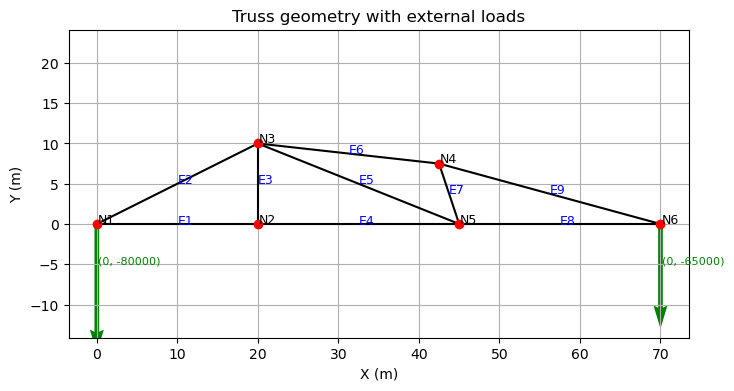

Length: 20.0
cos: 1.0
sin: 0.0
ke:
 [[ 5.25e+08  0.00e+00 -5.25e+08 -0.00e+00]
 [ 0.00e+00  0.00e+00 -0.00e+00 -0.00e+00]
 [-5.25e+08 -0.00e+00  5.25e+08  0.00e+00]
 [-0.00e+00 -0.00e+00  0.00e+00  0.00e+00]]


In [78]:
from input_data import nodes, elements, loads, fixed_dofs, E
from solver import element_stiffness, node_dofs
import matplotlib.pyplot as plt


plt.figure(figsize=(8, 4))

# elementen tekenen
for eid, elem in elements.items():
    n1 = elem["n1"]
    n2 = elem["n2"]

    x1, y1 = nodes[n1]
    x2, y2 = nodes[n2]

    plt.plot([x1, x2], [y1, y2], 'k-')

    xm = (x1 + x2) / 2
    ym = (y1 + y2) / 2
    plt.text(xm, ym, f"E{eid}", color="blue", fontsize=9)

# nodes tekenen
for node_id, (x, y) in nodes.items():
    plt.plot(x, y, 'ro')
    plt.text(x + 0.1, y + 0.1, f"N{node_id}", fontsize=9)

# belastingen tekenen
scale = 5000  # aanpassen voor zichtbare pijlen
for node_id, (Fx, Fy) in loads.items():
    x, y = nodes[node_id]
    plt.quiver(
        x, y,
        Fx / scale, Fy / scale,
        angles='xy',
        scale_units='xy',
        scale=1,
        color='green'
    )
    plt.text(x + 0.2, y - 5, f"({Fx:.0f}, {Fy:.0f})", fontsize=8, color="green")

plt.axis('equal')
plt.title("Truss geometry with external loads")
plt.xlabel("X (m)")
plt.ylabel("Y (m)")
plt.grid(True)
plt.show()


# Analyse 1-staaf element

elem = elements[1]
n1 = elem["n1"]
n2 = elem["n2"]

x1, y1 = nodes[n1]
x2, y2 = nodes[n2]

from solver import element_stiffness

ke, L, c, s = element_stiffness(x1, y1, x2, y2, E, elem["A"])

print("Length:", L)
print("cos:", c)
print("sin:", s)
print("ke:\n", ke)

In [79]:
from input_data import nodes, elements, E
from solver import node_dofs, element_stiffness, assemble_K

K = assemble_K(nodes, elements, E)

print(K)
print(K.shape)

[[ 5.62565942e+08  1.87829710e+07 -5.25000000e+08  0.00000000e+00
  -3.75659420e+07 -1.87829710e+07  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 1.87829710e+07  9.39148551e+06  0.00000000e+00  0.00000000e+00
  -1.87829710e+07 -9.39148551e+06  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [-5.25000000e+08  0.00000000e+00  7.77000000e+08  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  -2.52000000e+08  0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.26000000e+09
   0.00000000e+00 -1.26000000e+09  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00]
 [-3.75659420e+07 -1.87829710e+07  0.00000000e+00  0.00000000e+00
   1.16998818e+08  2.45443205e+05 -4.58156161e+07  5.09062401e+06
  -3.36172595e+07  1.34469038e+07  0.00000000e+00  0.00000000e+00]
 [-1.

In [80]:
import numpy as np
print(np.allclose(K, K.T))

True


In [81]:
n_dofs = 2 * len(nodes)
f = np.zeros(n_dofs)

for node_id, (Fx, Fy) in loads.items():
    dofs = node_dofs(node_id)
    f[dofs[0]] += Fx
    f[dofs[1]] += Fy

print("\nGlobal load vector f:")
print(f)


Global load vector f:
[     0. -80000.      0.      0.      0.      0.      0.      0.      0.
      0.      0. -65000.]


In [82]:
print("len(f) =", len(f))
print("expected =", 2 * len(nodes))

len(f) = 12
expected = 12


In [83]:
print("DOFs node 1:", node_dofs(1))
print("f[0] =", f[0])
print("f[0] =", f[1])

DOFs node 1: [0, 1]
f[0] = 0.0
f[0] = -80000.0


In [84]:
print("DOFs node 6:", node_dofs(6))
print("f[10] =", f[10])
print("f[11] =", f[11])

DOFs node 6: [10, 11]
f[10] = 0.0
f[11] = -65000.0


In [85]:
for i, value in enumerate(f):
    if value != 0:
        print(f"DOF {i}: {value}")

DOF 1: -80000.0
DOF 11: -65000.0


In [86]:
fixed = []

for node_id, (fix_x, fix_y) in fixed_dofs.items():
    dofs = node_dofs(node_id)

    if fix_x:
        fixed.append(dofs[0])
    if fix_y:
        fixed.append(dofs[1])

fixed = np.array(sorted(fixed))
print("Fixed DOFs:", fixed)

Fixed DOFs: [2 3 4]


In [87]:
n_dofs = 2 * len(nodes)
all_dofs = np.arange(n_dofs)
free = np.setdiff1d(all_dofs, fixed)

print("All DOFs: ", all_dofs)
print("Free DOFs:", free)
print("Fixed DOFs:", fixed)

All DOFs:  [ 0  1  2  3  4  5  6  7  8  9 10 11]
Free DOFs: [ 0  1  5  6  7  8  9 10 11]
Fixed DOFs: [2 3 4]


In [88]:
K_ff = K[np.ix_(free, free)]
f_f = f[free]

u = np.zeros(n_dofs)
u[free] = np.linalg.solve(K_ff, f_f)

In [89]:
print("Displacements:")
print(u)

Displacements:
[ 0.00030476 -0.00924296  0.          0.          0.         -0.00011508
  0.00390972 -0.00912646 -0.00128968 -0.01077594 -0.00270833 -0.05888072]


In [90]:
print(u[fixed])

[0. 0. 0.]


In [91]:
reactions = K @ u - f
print(reactions)
Fx_total = np.sum(f[0::2])
Fy_total = np.sum(f[1::2])

Rx_total = np.sum(reactions[0::2])
Ry_total = np.sum(reactions[1::2])

print("Fx balance:", Fx_total + Rx_total)
print("Fy balance:", Fy_total + Ry_total)

[ 0.00000000e+00  1.45519152e-11  1.65000000e+05  1.45000000e+05
 -1.65000000e+05  1.45519152e-11  4.65661287e-10 -9.31322575e-10
  0.00000000e+00  0.00000000e+00 -3.20142135e-10 -2.18278728e-11]
Fx balance: 5.820766091346741e-11
Fy balance: -2.6193447411060333e-10


In [92]:
from solver import compute_axial_forces

reactions
forces = compute_axial_forces(nodes, elements, E, u)
forces

{1: np.float64(-159999.99999999997),
 2: np.float64(178885.43819998312),
 3: np.float64(-145000.0000000007),
 4: np.float64(-325000.00000000175),
 5: np.float64(107703.2961426919),
 6: np.float64(226384.62845343564),
 7: np.float64(-42163.70213557972),
 8: np.float64(-238333.33333333372),
 9: np.float64(247038.00877147992)}

In [93]:
forces = {}

for eid, elem in elements.items():
    n1 = elem["n1"]
    n2 = elem["n2"]
    A = elem["A"]

    x1, y1 = nodes[n1]
    x2, y2 = nodes[n2]

    dx = x2 - x1
    dy = y2 - y1
    L = np.sqrt(dx**2 + dy**2)

    c = dx / L
    s = dy / L

    dofs = node_dofs(n1) + node_dofs(n2)
    u_elem = u[dofs]

    delta = np.array([-c, -s, c, s]) @ u_elem
    N = E * A / L * delta

    forces[eid] = N

for eid, N in forces.items():
    print(f"Element {eid}: N = {N:.3f} N")

Element 1: N = -160000.000 N
Element 2: N = 178885.438 N
Element 3: N = -145000.000 N
Element 4: N = -325000.000 N
Element 5: N = 107703.296 N
Element 6: N = 226384.628 N
Element 7: N = -42163.702 N
Element 8: N = -238333.333 N
Element 9: N = 247038.009 N


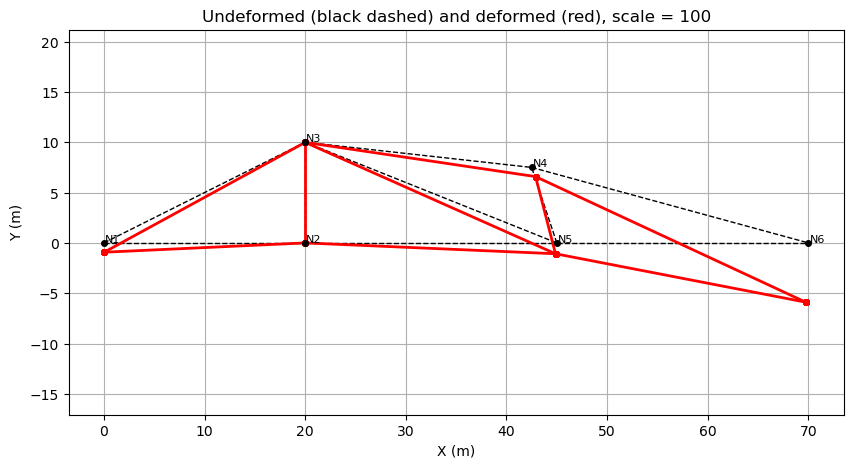

In [94]:
import matplotlib.pyplot as plt
import numpy as np
from solver import node_dofs

scale = 100  # vervorming zichtbaar maken; later aanpassen

plt.figure(figsize=(10, 5))

# 1. oorspronkelijke structuur
for eid, elem in elements.items():
    n1 = elem["n1"]
    n2 = elem["n2"]

    x1, y1 = nodes[n1]
    x2, y2 = nodes[n2]

    plt.plot([x1, x2], [y1, y2], 'k--', linewidth=1)

# 2. vervormde structuur
for eid, elem in elements.items():
    n1 = elem["n1"]
    n2 = elem["n2"]

    x1, y1 = nodes[n1]
    x2, y2 = nodes[n2]

    dofs1 = node_dofs(n1)
    dofs2 = node_dofs(n2)

    ux1, uy1 = u[dofs1[0]], u[dofs1[1]]
    ux2, uy2 = u[dofs2[0]], u[dofs2[1]]

    x1_def = x1 + scale * ux1
    y1_def = y1 + scale * uy1
    x2_def = x2 + scale * ux2
    y2_def = y2 + scale * uy2

    plt.plot([x1_def, x2_def], [y1_def, y2_def], 'r-', linewidth=2)

    for node_id, (x, y) in nodes.items():
        dofs = node_dofs(node_id)
        ux, uy = u[dofs[0]], u[dofs[1]]
    
        x_def = x + scale * ux
        y_def = y + scale * uy
    
        plt.plot(x_def, y_def, 'ro', markersize=4)

# 3. nodes van onvervormde geometrie
for node_id, (x, y) in nodes.items():
    plt.plot(x, y, 'ko', markersize=4)
    plt.text(x + 0.1, y + 0.1, f'N{node_id}', fontsize=8)

plt.axis('equal')
plt.title(f"Undeformed (black dashed) and deformed (red), scale = {scale}")
plt.xlabel("X (m)")
plt.ylabel("Y (m)")
plt.grid(True)
plt.show()

In [95]:
print("Max displacement in [m]:", np.max(np.abs(u)))

Max displacement in [m]: 0.05888072421527591
